In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import moocore

In [2]:
df_memory = pd.read_csv("model_sizes.csv")
df_memory = df_memory[df_memory["seed"] == 888]
df_memory.drop_duplicates(inplace=True)
df_memory

,idx,seed,key,espdl_size_bytes,torch_size_bytes
1,1,888,0,928960,3768065
4,2,888,0,699248,2755057
7,3,888,0,175104,531436
10,4,888,0,247280,937689
13,5,888,0,552240,2056685
...,...,...,...,...,...
31656,14649,888,200,183472,581224
31658,14650,888,200,518608,1853475
31660,14653,888,200,239072,829779
31662,14654,888,200,956816,3773535


In [4]:
df_accuracy = pd.read_csv("result.csv")
df_accuracy = df_accuracy[df_accuracy["seed"] == 888]
df_accuracy.drop_duplicates(inplace=True)
df_accuracy = df_accuracy[df_accuracy["dataset"] == "cifar10"]
df_accuracy

,idx,seed,dataset,accuracy_fp32,accuracy_esp
163,763,888,cifar10,75.55,18.68
167,931,888,cifar10,62.55,15.64
171,1296,888,cifar10,73.62,30.27
185,379,888,cifar10,87.19,84.66
201,113,888,cifar10,87.09,71.13
...,...,...,...,...,...
39296,14896,888,cifar10,91.80,91.75
39406,4461,888,cifar10,87.45,82.22
40585,5144,888,cifar10,93.07,92.52
41133,7045,888,cifar10,89.85,89.40


In [12]:
df_hwnas = pd.read_csv("../all_hwnas.csv", index_col=0)
df_hwnas.columns

Index(['edgegpu_latency', 'edgegpu_energy', 'raspi4_latency',
       'edgetpu_latency', 'pixel3_latency', 'eyeriss_latency',
       'eyeriss_energy', 'eyeriss_arithmetic_intensity', 'fpga_latency',
       'fpga_energy', 'average_hw_metric', 'arch_index', 'seed', 'flop',
       'test_acc', 'dataset', 'arch_0', 'arch_1', 'arch_2', 'arch_3', 'arch_4',
       'arch_5'],
      dtype='object')

In [15]:
df_merged = df_accuracy.merge(df_memory).merge(df_hwnas, left_on = ["seed", "idx", "dataset"], right_on = ["seed", "arch_index", "dataset"])
df_merged.to_csv("../results/alldata.csv", index=False)

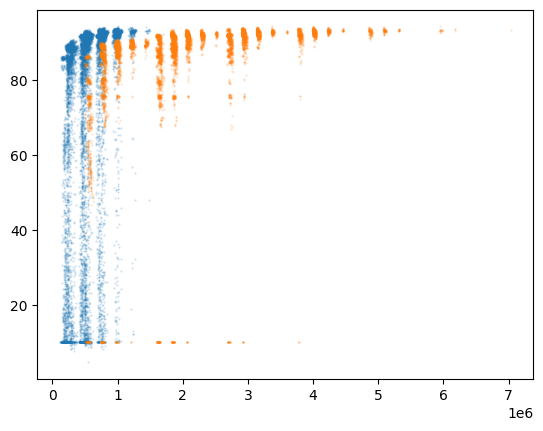

In [11]:
plt.scatter(df_merged["espdl_size_bytes"], df_merged["accuracy_esp"], alpha = 0.2, s=0.3)
plt.scatter(df_merged["torch_size_bytes"], df_merged["accuracy_fp32"], alpha = 0.2, s=0.3)
plt.savefig("sizevsacc.png")
plt.show()

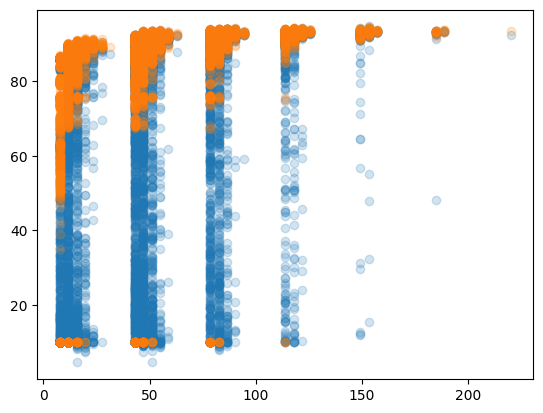

In [37]:
plt.scatter(df_merged["flop"], df_merged["esp_acc"], alpha = 0.2)
plt.scatter(df_merged["flop"], df_merged["fp32_acc"], alpha = 0.2)
plt.show()

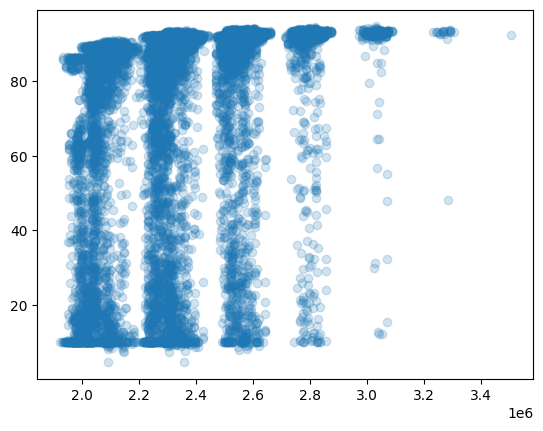

In [38]:
plt.scatter(df_merged["Unnamed: 28"], df_merged["esp_acc"], alpha = 0.2)
plt.show()